In [1]:
import pandas as pd
import numpy as np

In [9]:
df = pd.read_excel("/content/plant data.xlsx")

In [21]:
df.shape

(9568, 5)

In [14]:
df.head()


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [16]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [19]:
df.duplicated().sum()

np.int64(41)

In [20]:
df.drop_duplicates().copy()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


In [25]:
df = df.drop_duplicates()

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.shape

(9527, 5)

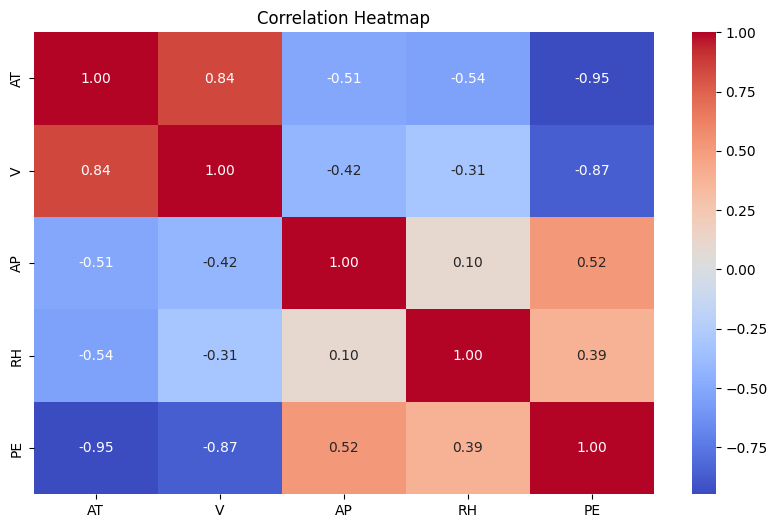

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
plt.figure(figsize=(10, 6))  # Adjust size as needed
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()


In [29]:

df.to_csv("cleaned_data.csv", index=False)

print("Cleaned data saved as cleaned_data.csv")


Cleaned data saved as cleaned_data.csv


Dataset shape: (9527, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


Independent variables: ['AT', 'V', 'AP', 'RH']
Number of independent variables: 4
Total samples: 9527
Training samples: 7621
Testing samples: 1906
XGBoost training completed!

XGBoost Model Performance
--------------------------------
R² Score: 0.9609
MAE: 2.4162 MW
RMSE: 3.3887 MW

Actual vs Predicted Power Output:


,Actual Power Output (MW),Predicted Power Output (MW)
0,463.57,465.163361
1,441.31,444.769531
2,445.34,445.574585
3,465.42,464.336121
4,439.06,438.102936
5,442.02,444.237671
6,471.48,475.111969
7,478.34,473.395416
8,445.90,447.367157
9,464.18,463.253326


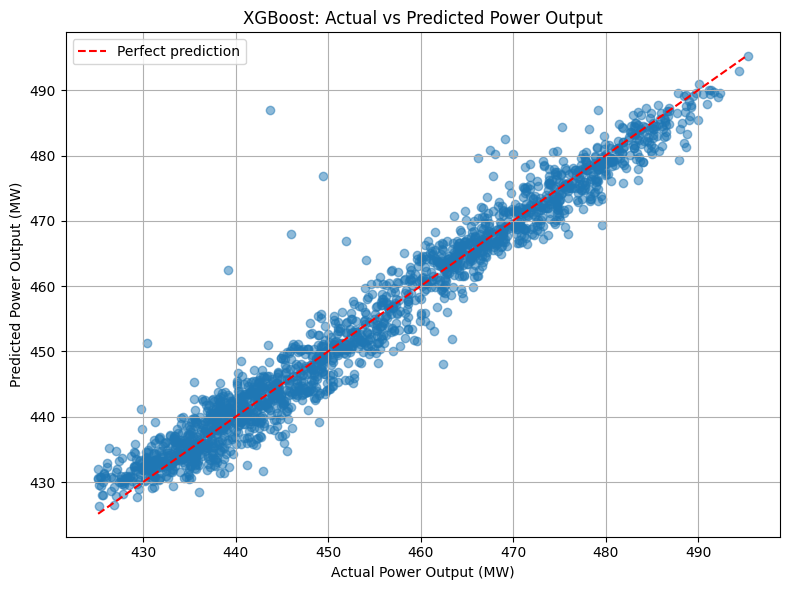

In [36]:
!pip -q install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 1. Load cleaned dataset
df = pd.read_csv("/content/cleaned_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

# 2. Select independent variables and target
features = ["AT", "V", "AP", "RH"]
target = "PE"

X = df[features].copy()
y = df[target].copy()

# Convert features and target to numeric
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# Remove rows with missing target values
valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]

print("Independent variables:", features)
print("Number of independent variables:", len(features))
print("Total samples:", len(X))

# 3. Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# 4. Handle missing values
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=features,
    index=X_test.index
)

# 5. Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 6. Train model
xgb_model.fit(X_train, y_train)

print("XGBoost training completed!")

# 7. Make predictions
y_pred = xgb_model.predict(X_test)

# 8. Evaluate model
print("\nXGBoost Model Performance")
print("--------------------------------")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f} MW")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} MW")

# 9. Actual vs predicted values
results = pd.DataFrame({
    "Actual Power Output (MW)": y_test.values,
    "Predicted Power Output (MW)": y_pred
})

print("\nActual vs Predicted Power Output:")
display(results.head(10))

# 10. Actual vs predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot([low, high], [low, high], "r--", label="Perfect prediction")

plt.xlabel("Actual Power Output (MW)")
plt.ylabel("Predicted Power Output (MW)")
plt.title("XGBoost: Actual vs Predicted Power Output")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


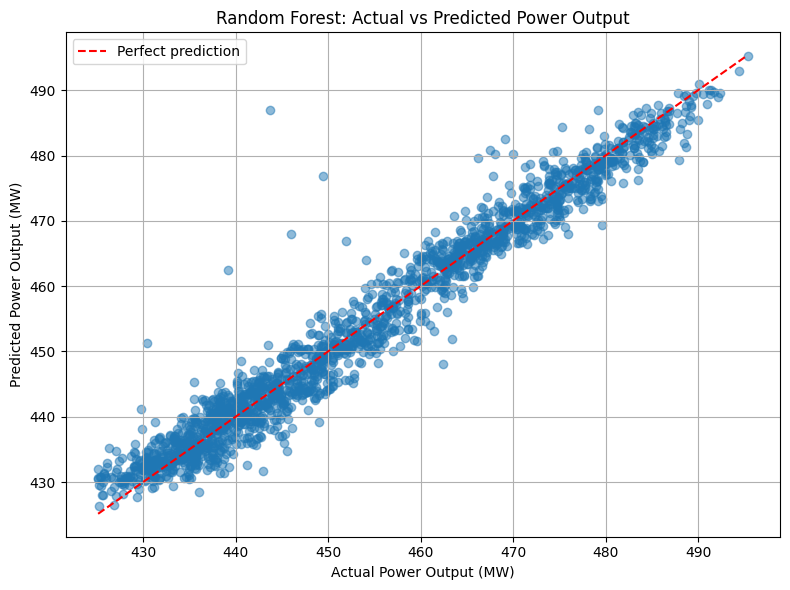

In [37]:

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot(
    [low, high],
    [low, high],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual Power Output (MW)")
plt.ylabel("Predicted Power Output (MW)")
plt.title("Random Forest: Actual vs Predicted Power Output")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Dataset shape: (9527, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


Independent variables: ['AT', 'V', 'AP', 'RH']
Number of independent variables: 4
Total samples: 9527
Training samples: 7621
Testing samples: 1906
Random Forest training completed!

Random Forest Model Performance
--------------------------------
R² Score: 0.9599
MAE: 2.4070 MW
RMSE: 3.4329 MW

Actual vs Predicted Power Output:


,Actual Power Output (MW),Predicted Power Output (MW)
0,463.57,464.490833
1,441.31,443.345200
2,445.34,444.429767
3,465.42,463.180367
4,439.06,437.014500
5,442.02,444.935667
6,471.48,475.518233
7,478.34,476.241833
8,445.90,447.805467
9,464.18,466.583733


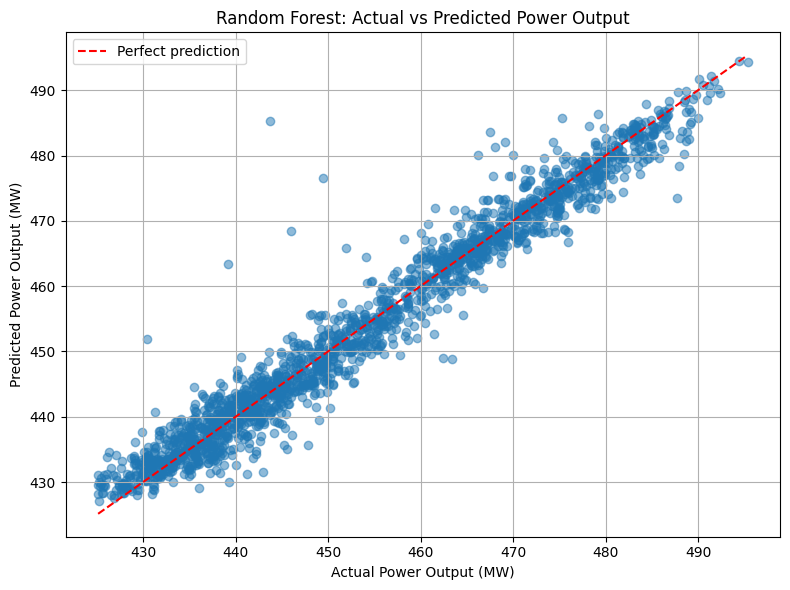

In [34]:


!pip -q install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 1. Load cleaned dataset
df = pd.read_csv("/content/cleaned_data.csv")

print("Dataset shape:", df.shape)
display(df.head())

# 2. Select independent variables and target

# Input features
features = ["AT", "V", "AP", "RH"]

# Target variable
target = "PE"

X = df[features].copy()
y = df[target].copy()

# Convert features and target to numeric
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# Remove rows with missing target values
valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]

print("Independent variables:", features)
print("Number of independent variables:", len(features))
print("Total samples:", len(X))

# 3. Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# 4. Handle missing values
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=features,
    index=X_test.index
)

# 5. Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

# 6. Train model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

# 7. Make predictions
y_pred = rf_model.predict(X_test)

# 8. Evaluate model
print("\nRandom Forest Model Performance")
print("--------------------------------")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f} MW")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} MW")

# 9. Actual vs predicted values
results = pd.DataFrame({
    "Actual Power Output (MW)": y_test.values,
    "Predicted Power Output (MW)": y_pred
})

print("\nActual vs Predicted Power Output:")
display(results.head(10))

# 10. Actual vs predicted plot
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot(
    [low, high],
    [low, high],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual Power Output (MW)")
plt.ylabel("Predicted Power Output (MW)")
plt.title("Random Forest: Actual vs Predicted Power Output")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Number of features: 4
Total samples: 9527
Training samples: 7621
Testing samples: 1906
SVR training completed!

SVR Model Performance
----------------------
R² Score: 0.9437
MAE: 2.9929 MW
RMSE: 4.0676 MW

Actual vs Predicted Power Output:


,Actual Power Output (MW),Predicted Power Output (MW)
0,463.57,466.239025
1,441.31,446.595017
2,445.34,447.747353
3,465.42,466.118447
4,439.06,434.783172
5,442.02,442.143315
6,471.48,476.303149
7,478.34,476.980463
8,445.90,447.185891
9,464.18,461.679941


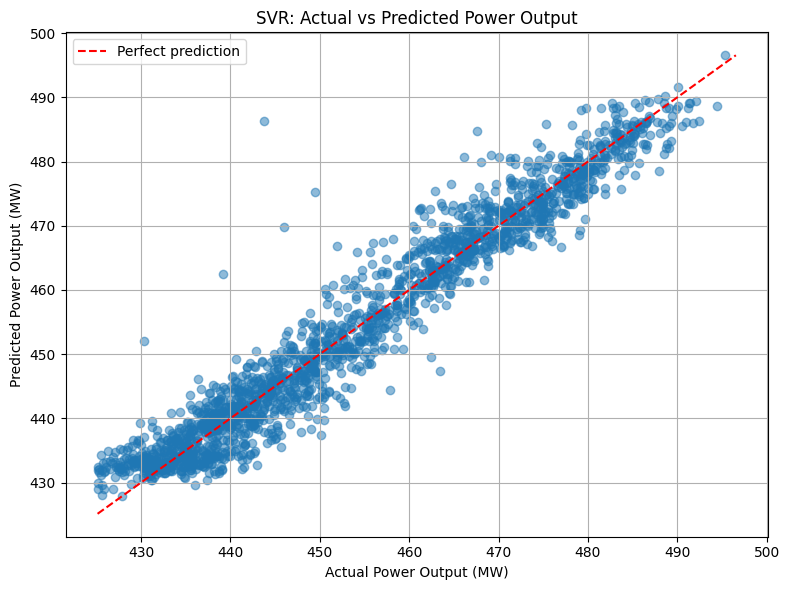

In [35]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 1. Load cleaned dataset
df = pd.read_csv("/content/cleaned_data.csv")

# 2. Select input features and target
features = ["AT", "V", "AP", "RH"]
target = "PE"

X = df[features].copy()
y = df[target].copy()

# Convert to numeric
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# Replace infinite values
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# Remove rows with missing target
valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]

print("Number of features:", len(features))
print("Total samples:", len(X))

# 3. Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# 4. Handle missing values
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=features,
    index=X_test.index
)

# 5. Scale features (important for SVR)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Create SVR model
svr_model = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1,
    gamma="scale"
)

# 7. Train model
svr_model.fit(X_train_scaled, y_train)

print("SVR training completed!")

# 8. Make predictions
y_pred = svr_model.predict(X_test_scaled)

# 9. Evaluate model
print("\nSVR Model Performance")
print("----------------------")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f} MW")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} MW")

# 10. Actual vs predicted values
results = pd.DataFrame({
    "Actual Power Output (MW)": y_test.values,
    "Predicted Power Output (MW)": y_pred
})

print("\nActual vs Predicted Power Output:")
display(results.head(10))

# 11. Actual vs predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot(
    [low, high], [low, high],
    "r--", label="Perfect prediction"
)

plt.xlabel("Actual Power Output (MW)")
plt.ylabel("Predicted Power Output (MW)")
plt.title("SVR: Actual vs Predicted Power Output")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
!pip install shap
